# Predictive Analytics: The Zen of Five — Heart Failure Patient Dataset
### Top 20 Predictive Analysis Questions — with Reasoning, Analysis, and Insight

**What is predictive analysis?** It answers **"what is likely to happen?"** by building statistical/ML
models on historical data to forecast future outcomes for new or existing patients — mortality risk,
readmission likelihood, length of stay, lab trajectories, and more.

This notebook works through **20 predictive questions**, using the same cardiology inpatient dataset
(2,008 patients, 200 variables) as the earlier prescriptive-analysis notebook. Each question follows:

1. **Reasoning** — why this prediction matters and how it would be used clinically/operationally
2. **Analysis** — the model(s) built to answer it (classification, regression, or multi-class), with
   proper train/test splitting, evaluation metrics, and visualizations
3. **Insight** — what the model tells us and how confident we should be in it

> Dataset file: `Team4_The_Zen_Of_Five_cleaned_data.csv` — place this CSV in the same folder as this
> notebook (the loader below also checks a couple of common fallback locations and will tell you exactly
> where it looked if it can't find the file).


## 0. Setup & Data Load

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (roc_auc_score, roc_curve, accuracy_score, precision_recall_curve,
                              mean_absolute_error, r2_score, confusion_matrix, ConfusionMatrixDisplay,
                              brier_score_loss)
from sklearn.calibration import calibration_curve

pd.set_option('display.max_columns', 60)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)
RANDOM_STATE = 42


In [ ]:
# Robust CSV loader
FILENAME = 'cardiac_failure/Team4_The_Zen_Of_Five_cleaned_data.csv'
candidate_paths = [
    FILENAME,
    os.path.join(os.getcwd(), FILENAME),
    os.path.join(os.path.expanduser('~'), 'Downloads', FILENAME),
    os.path.join(os.path.expanduser('~'), 'Desktop', FILENAME),
]

df = None
for p in candidate_paths:
    if os.path.exists(p):
        df = pd.read_csv(p)
        print(f"Loaded data from: {p}")
        break

if df is None:
    raise FileNotFoundError(
        f"Could not find '{FILENAME}'. Looked in:\n  " + "\n  ".join(candidate_paths) +
        f"\n\nCurrent working directory is: {os.getcwd()}\n"
        "Fix: move the CSV into this folder, or edit candidate_paths above."
    )

print("Shape:", df.shape)
df.head(3)


# Q1: Can we predict, using only information available at admission, whether a heart failure patient will be readmitted within 6 months — so hospitals can act preventively rather than reactively?

#  Hypotheses
**H₀ (null):** Admission-time clinical features (vitals, labs, comorbidity burden, HF type, demographics) have no predictive relationship with 6-month readmission — readmission is effectively random with respect to these variables.


**H₁ (alternate):** Admission-time clinical features do carry predictive signal for 6-month readmission — a model trained on them will perform meaningfully better than random guessing (AUC > 0.5).

Parameters / Features Used

# Objective:

**Objective is to predict the rate of readmission within 6 months at the time of admission itself**


# Reasoning:
Doctors want to know, right when a heart failure patient walks in, whether that patient is likely to come back to the hospital within the next 6 months — so they can step in early (extra follow-up, medication checks) instead of just waiting and reacting after it happens. We can only use information available at the moment of admission, since anything that happens after discharge wouldn't help the hospital plan ahead. Testing this with a prediction model tells us honestly how much the admission data alone can (or can't) forecast — which is genuinely useful either way.

### Parameters and Their Clinical Connection to Readmission Risk

| Parameter | Type | Connection to 6-month readmission risk |
|---|---|---|
| `cci_score` | Numeric | More chronic conditions on board means more competing health problems that can independently trigger a return trip to the hospital, not just the heart itself. |
| `systolic_blood_pressure` | Numeric | Abnormally low BP at admission can signal poor cardiac output; a key marker of hemodynamic instability. |
| `diastolic_blood_pressure` | Numeric | High or low diastolic pressure reflects vascular tone/uncontrolled hypertension, a common driver of HF decompensation. |
| `pulse` | Numeric | An elevated resting heart rate suggests the heart is compensating for reduced pumping efficiency — a sign of instability. |
| `brain_natriuretic_peptide` | Numeric | Directly measures cardiac wall stress from fluid overload — the single most HF-specific lab in the dataset, and a well-established readmission predictor. |
| `creatinine_enzymatic_method` | Numeric | Poor kidney function limits how aggressively diuretics can be used, tied to cardiorenal syndrome risk — a known driver of bounce-back admissions. |
| `sodium` | Numeric | Low sodium (hyponatremia) reflects how far the body has fallen into fluid-retention compensation — already linked to worse outcomes in this analysis. |
| `potassium` | Numeric | Electrolyte imbalance risk, especially relevant with diuretic/MRA use — abnormal levels can precipitate an event requiring readmission. |
| `hemoglobin` | Numeric | Anemia increases cardiac workload (the heart pumps harder to deliver oxygen), independently worsening HF prognosis. |
| `white_blood_cell` | Numeric | Can flag an underlying infection triggering the HF episode — a root cause that, if missed, could resurface after discharge. |
| `platelet` | Numeric | General marker of physiological stress; included as a broad stability indicator. |
| `lvef` | Numeric | Defines HF type and severity (HFrEF vs. HFpEF) — directly tied to which medications are indicated and how fragile pumping function is. |
| `total_prescriptions_count` | Numeric | Proxy for medication complexity/polypharmacy — more medications can mean better guideline coverage, but also more risk of confusion managing them at home. |
| `gender` | Categorical | Demographic context capturing baseline risk differences not reflected in labs alone. |
| `bmi_category` | Categorical | Body-composition context; both very low and very high BMI carry distinct HF risk profiles. |
| `admission_way` | Categorical | How urgently the patient arrived (Emergency vs. Non-Emergency) reflects how destabilized they already were before hospitalization. |
| `type_of_heart_failure` | Categorical | Biventricular (both-sided) failure — the most common and most advanced form in this cohort — may carry distinct readmission risk from isolated left- or right-sided failure. |
| `nyha_cardiac_function_classification` | Categorical | Captures how limited the patient's daily life already was *before* this admission — a direct measure of chronic disease severity. |

### Target Variable

| Parameter | Value |
|---|---|
| Target column | `re_admission_within_6_months` |
| Type | Binary classification |
| 0 = | Not readmitted within 6 months |
| 1 = | Readmitted within 6 months |
| Why this target | Predicting this at admission lets hospitals act preventively (early follow-up, case management) instead of reacting after the patient bounces back. |

In [ ]:

# ============================================================
# CORRELATION CHECK
# ============================================================

# --- 1. Correlation matrix among numeric features (check for multicollinearity) ---

numeric_cols = ['cci_score', 'systolic_blood_pressure', 'diastolic_blood_pressure', 'pulse',
                 'brain_natriuretic_peptide', 'creatinine_enzymatic_method', 'sodium', 'potassium',
                 'hemoglobin', 'white_blood_cell', 'platelet', 'lvef', 'total_prescriptions_count']

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'label': 'Correlation'})
plt.title('Correlation matrix — numeric features')
plt.tight_layout(); plt.show()

In [ ]:
# --- 2. Flag any highly correlated feature pairs (potential redundancy) ---

corr_pairs = corr_matrix.abs().unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1.0]  # remove self-correlation (always 1.0)
corr_pairs = corr_pairs[~corr_pairs.index.duplicated()]  # remove mirrored duplicates

print("Top 10 most correlated feature pairs:")
print(corr_pairs.head(10))
print()
print("Pairs with |correlation| > 0.6 (potential multicollinearity to watch for):")
print(corr_pairs[corr_pairs > 0.6])

# --- 3. Correlation of each numeric feature with the TARGET variable ---

target_corr = df[numeric_cols + ['re_admission_within_6_months']].corr()['re_admission_within_6_months'].drop('re_admission_within_6_months')
target_corr = target_corr.sort_values(key=abs, ascending=False)

print("Correlation of each feature with 6-month readmission:")
print(target_corr)

plt.figure(figsize=(8, 6))
target_corr.plot(kind='barh', color=['crimson' if v > 0 else 'steelblue' for v in target_corr])
plt.xlabel('Correlation with re_admission_within_6_months')
plt.title('Feature correlation with readmission target')
plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()

**Correlation matrix:** watch for any two features with correlation above ~0.7-0.8 — that's a sign of redundancy (multicollinearity), which can make a Logistic Regression's coefficients unstable (though tree-based models like Random Forest/Gradient Boosting handle it fine).

**Target correlation:** individual correlations with a binary outcome are usually fairly weak (often under 0.15-0.2 in real clinical data) — that's normal and expected, and it's consistent with your earlier finding that no single lab alone strongly predicts readmission, which is why you needed a combined model/score instead of one variable.

# Checking categorical values:

In [ ]:

cat_cols = ['gender', 'bmi_category', 'admission_way', 'type_of_heart_failure',
            'nyha_cardiac_function_classification']

for col in cat_cols:
    print(f"--- {col} ---")
    print(df[col].value_counts(dropna=False))
    print()

In [ ]:
for col in cat_cols:
    print(f"--- Readmission rate by {col} ---")
    print(df.groupby(col)['re_admission_within_6_months'].mean().sort_values(ascending=False))
    print()

# Model Building:

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

target = 're_admission_within_6_months'
numeric_cols = ['cci_score', 'systolic_blood_pressure', 'diastolic_blood_pressure', 'pulse',
                 'brain_natriuretic_peptide', 'creatinine_enzymatic_method', 'sodium', 'potassium',
                 'hemoglobin', 'white_blood_cell', 'platelet', 'lvef', 'total_prescriptions_count']
cat_cols = ['gender', 'bmi_category', 'admission_way', 'type_of_heart_failure',
            'nyha_cardiac_function_classification']

use_cols = numeric_cols + cat_cols
X = df[use_cols].copy()
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

preprocess = ColumnTransformer([
    ('num', Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())]), numeric_cols),
    ('cat', Pipeline([('impute', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(handle_unknown='ignore'))]), cat_cols)
])

models = {
    'LogisticRegression': LogisticRegression(max_iter=2000, class_weight='balanced'),
    'DecisionTree': DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=400, class_weight='balanced', random_state=42),
    'GradientBoosting': GradientBoostingClassifier(random_state=42)
}

results = {}
for name, model in models.items():
    pipe = Pipeline([('prep', preprocess), ('clf', model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]
    results[name] = {
        'accuracy': accuracy_score(y_test, preds),
        'precision': precision_score(y_test, preds),
        'recall': recall_score(y_test, preds),
        'f1': f1_score(y_test, preds),
        'auc': roc_auc_score(y_test, proba)
    }

results_df = pd.DataFrame(results).T.round(3)
print(results_df)

In [ ]:
metrics = ['accuracy', 'precision', 'recall', 'f1']
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for ax, metric in zip(axes.ravel(), metrics):
    results_df[metric].sort_values(ascending=False).plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title(metric.capitalize())
    ax.set_ylabel(metric.capitalize())
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Model comparison: 6-month readmission prediction')
plt.tight_layout()
plt.show()

In [ ]:
plot_df = results_df[['accuracy','precision','recall','f1']].reset_index().melt(id_vars='index', var_name='Metric', value_name='Score')
plot_df = plot_df.rename(columns={'index':'Model'})

plt.figure(figsize=(10,6))
sns.barplot(data=plot_df, x='Model', y='Score', hue='Metric')
plt.ylim(0, 1)
plt.title('Model comparison across all metrics')
plt.xticks(rotation=15)
plt.legend(title='', loc='upper right')
plt.tight_layout(); plt.show()

# Choosing one final model

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, RocCurveDisplay

# Rebuild the chosen pipeline (Logistic Regression -- best recall/F1)
final_model_name = 'LogisticRegression'
final_pipe = Pipeline([('prep', preprocess), ('clf', models[final_model_name])])
final_pipe.fit(X_train, y_train)

final_preds = final_pipe.predict(X_test)
final_proba = final_pipe.predict_proba(X_test)[:, 1]

print(f"Final model: {final_model_name}")
print(classification_report(y_test, final_preds))

In [ ]:
cm = confusion_matrix(y_test, final_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: No readmit', 'Predicted: Readmit'],
            yticklabels=['Actual: No readmit', 'Actual: Readmit'])
plt.title(f'Confusion Matrix — {final_model_name}')
plt.tight_layout(); plt.show()

In [ ]:
RocCurveDisplay.from_predictions(y_test, final_proba)
plt.title(f'ROC Curve — {final_model_name} (AUC = {results[final_model_name]["auc"]:.3f})')
plt.tight_layout(); plt.show()

In [ ]:
feat_names = final_pipe.named_steps['prep'].get_feature_names_out()
coefs = final_pipe.named_steps['clf'].coef_[0]
importance = pd.Series(coefs, index=feat_names).sort_values(key=abs, ascending=False).head(15)

print("Top 15 predictors (positive = raises risk, negative = lowers risk):")
print(importance)

plt.figure(figsize=(8,6))
importance.plot(kind='barh', color=['crimson' if v>0 else 'steelblue' for v in importance])
plt.xlabel('Coefficient (Logistic Regression)')
plt.title('Top predictors of 6-month readmission')
plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()

In [ ]:
# Get predicted probability for every patient in the test set
risk_output = pd.DataFrame({
    'inpatient_number': df.loc[X_test.index, 'inpatient_number'],
    'predicted_risk': final_proba,
    'actual_readmit': y_test.values
})

# Split into 3 risk tiers
risk_output['risk_tier'] = pd.qcut(risk_output['predicted_risk'], q=3, labels=['Low', 'Medium', 'High'])

print("Actual readmission rate by model-predicted risk tier:")
print(risk_output.groupby('risk_tier')['actual_readmit'].agg(['mean', 'count']))

In [ ]:
flag_killip = df['killip_grade'] >= 3
flag_sodium = df['sodium'] < 135
flag_lactate = df['lactate'] > 2
flag_cci = df['cci_score'] >= df['cci_score'].quantile(0.75)
flag_bnp = df['brain_natriuretic_peptide'] >= df['brain_natriuretic_peptide'].quantile(0.75)

on_bb = (df['rx_metoprolol_succinate_sustained-release_tablet'] == 1) | (df['rx_metoprolol_tartrate_injection'] == 1)
on_acei = (df['rx_valsartan_dispersible_tablet'] == 1) | (df['rx_benazepril_hydrochloride_tablet'] == 1)
on_mra = (df['rx_spironolactone_tablet'] == 1)
gdmt_count = on_bb.astype(int) + on_acei.astype(int) + on_mra.astype(int)
flag_gdmt = (df['lvef'] <= 40) & (gdmt_count < 3)

df['followup_score'] = (flag_killip.fillna(False).astype(int) + flag_sodium.fillna(False).astype(int) +
                         flag_lactate.fillna(False).astype(int) + flag_cci.fillna(False).astype(int) +
                         flag_bnp.fillna(False).astype(int) + flag_gdmt.fillna(False).astype(int))

In [ ]:
# ============================================================
# STEP 15: FINAL EXECUTIVE SUMMARY
# ============================================================

print("="*70)
print("CARDIAC FAILURE ANALYTICS -- EXECUTIVE SUMMARY")
print("="*70)

# --- Descriptive highlights ---
print("\n--- DESCRIPTIVE ---")
print(f"Total patients: {len(df)}")
print(f"Biventricular (both-sided) HF: {(df['type_of_heart_failure']=='Both').mean()*100:.1f}%")
print(f"NYHA class 3-4 (markedly/severely limited): "
      f"{df['nyha_cardiac_function_classification'].isin([3,4]).mean()*100:.1f}%")
print(f"Killip grade 3-4 (severe signs at admission): {(df['killip_grade']>=3).mean()*100:.1f}%")
print(f"ICU admission rate: {(df['admission_ward']=='ICU').mean()*100:.1f}%")

low_na = df['sodium'] < 135
death_low_na = df.loc[low_na, 'death_within_6_months'].mean()*100
death_norm_na = df.loc[~low_na, 'death_within_6_months'].mean()*100
print(f"6-month death rate, hyponatremic vs normal sodium: {death_low_na:.1f}% vs {death_norm_na:.1f}%")

# --- Predictive highlights ---
print("\n--- PREDICTIVE ---")
print("Best model AUC (6-month readmission prediction):", round(max(r['auc'] for r in results.values()), 3))
print("Best model F1:", round(max(r['f1'] for r in results.values()), 3))
print("Conclusion: admission-day clinical data carries real, moderate predictive signal (H0 rejected)")

# --- Prescriptive highlights ---
print("\n--- PRESCRIPTIVE ---")

# Undertriage finding
crit_killip = df['killip_grade'] >= 3
crit_lactate = df['lactate'] > 2.15
crit_gcs = df['gcs'] < 15
crit_count = crit_killip.fillna(False).astype(int) + crit_lactate.fillna(False).astype(int) + crit_gcs.fillna(False).astype(int)
meets_2plus = crit_count >= 2
missed = meets_2plus & (df['admission_ward'] != 'ICU')
print(f"Patients meeting >=2 escalation criteria but NOT sent to ICU: {missed.sum()}")
print(f"  Death rate -- missed vs rest: {df.loc[missed,'death_within_6_months'].mean()*100:.1f}% "
      f"vs {df.loc[~missed,'death_within_6_months'].mean()*100:.1f}%")

# GDMT gap
hfref = df[df['lvef'] <= 40]
on_bb = (hfref['rx_metoprolol_succinate_sustained-release_tablet']==1) | (hfref['rx_metoprolol_tartrate_injection']==1)
on_acei = (hfref['rx_valsartan_dispersible_tablet']==1) | (hfref['rx_benazepril_hydrochloride_tablet']==1)
on_mra = (hfref['rx_spironolactone_tablet']==1)
gdmt_gap = (on_bb.astype(int)+on_acei.astype(int)+on_mra.astype(int)) < 3
print(f"\nHFrEF patients missing >=1 GDMT drug class: {gdmt_gap.sum()} ({gdmt_gap.mean()*100:.1f}% of HFrEF)")

# Resource efficiency
sorted_df = df.sort_values('followup_score', ascending=False).reset_index(drop=True)
sorted_df['cum_patients_pct'] = (sorted_df.index+1)/len(sorted_df)*100
sorted_df['cum_deaths_pct'] = sorted_df['death_within_6_months'].cumsum()/sorted_df['death_within_6_months'].sum()*100
idx = (sorted_df['cum_patients_pct']-44.7).abs().idxmin()
print(f"\nFlagging top {sorted_df.loc[idx,'cum_patients_pct']:.1f}% of patients by risk score "
      f"captures {sorted_df.loc[idx,'cum_deaths_pct']:.1f}% of all 6-month deaths")

print("\n" + "="*70)
print("CLOSING MESSAGE:")
print("We don't need to follow up with everyone -- we need to follow up")
print("with the right patients. This analysis identifies who they are.")
print("="*70)

Final Model Summary Table
Model	Accuracy	Precision	Recall	F1	AUC
Logistic Regression	0.584	0.469	0.617 ⭐	0.532 ⭐	0.624
Decision Tree	0.602	0.482	0.487	0.485	0.585 (lowest)
Random Forest	0.631 ⭐	0.544 ⭐	0.254 (lowest)	0.346	0.627
Gradient Boosting	0.616	0.500	0.332	0.399	0.640 ⭐

In [ ]:
results_df = pd.DataFrame(results).T.round(3)
results_df = results_df[['accuracy','precision','recall','f1','auc']]
results_df.style.highlight_max(color='lightgreen', axis=0)

Final Insights:
Random Forest looks best on paper (highest accuracy 0.631, highest precision 0.544) — but its recall is only 0.254, meaning it catches barely 1 in 4 patients who actually get readmitted. In a hospital setting, that's the dangerous kind of error: missing high-risk patients who needed intervention.
Gradient Boosting has the best AUC (0.640) — the best overall ranking ability — but its recall (0.332) is still weak in absolute terms.
Logistic Regression has the lowest accuracy of the four (0.584), but by far the best recall (0.617) and best F1 (0.532) — it correctly flags 62% of patients who will actually be readmitted. For a preventive-care program (which is the entire point of this analysis — catching at-risk patients before they bounce back), missing fewer true readmissions matters more than avoiding false alarms. A false alarm just means someone gets an unnecessary follow-up call; a missed case means a preventable readmission slips through.
Decision Tree is the weakest overall — lowest AUC, middling everywhere else — useful mainly as a simple, explainable baseline, not a final choice.

## Q2. Can we predict discharge destination (home vs. healthcare facility) accurately enough to start discharge planning on day 1?
## hypothesis:
## H₀ (null):
Day-1 admission data (demographics, vitals, comorbidities, clinical severity scores) provides no better than chance ability to predict whether a patient will be discharged home vs. to a healthcare facility.
## H₁ 
(alternative): Day-1 admission data predicts discharge destination significantly better than chance (i.e., a model trained on it achieves AUC meaningfully above 0.5).
We reject H₀ in a narrow, technical sense (5 of 41 parameters showed p < 0.05, and model AUC of 0.60 is above the 0.50 chance line), but fail to reject it in the practical/clinical sense — the effect size is too small (AUC 0.60, well below the ~0.70 threshold generally considered clinically actionable) to support building day-1 discharge planning on it. The interesting finding is which hypothesis category held up: administrative/logistic variables (Hypothesis 4) carried more signal than clinical severity (Hypotheses 1–2), which is somewhat counterintuitive and worth highlighting as a discussion point.

**Reasoning:** Complex discharge planning (facility placement, equipment, transport) takes days to arrange.
An accurate early-prediction model lets social work start that process at admission instead of at medical
readiness, shortening avoidable length of stay.

## Objective:

The objective of this analysis is to determine whether patient data available on day 1 of hospital admission — demographics, vital signs, comorbidity burden, and clinical severity scores (Killip grade, NYHA class, GCS/consciousness) — can predict a patient's eventual discharge destination (Home vs. Healthcare Facility) with sufficient accuracy to support discharge planning starting at admission, 
rather than waiting until closer to discharge.

## Reasoning:

Early discharge planning has real clinical and operational value: arranging a healthcare-facility bed, coordinating social work, or organizing family/home-care support all take time, and starting these processes late is a common cause of extended, avoidable length of stay. If day-1 data can reliably flag which patients are headed to a facility rather than home, hospitals could begin that coordination immediately instead of waiting for clinical stabilization.

The approach taken here reflects three deliberate choices:

Restricting features to day-1-only data. Anything recorded at or near discharge (dischargeday, discharge_department, outcome/readmission/death columns) was deliberately excluded, even though including it would inflate model performance. Using discharge-adjacent data to predict a discharge-time outcome would be data leakage — it would answer "does the discharge process correlate with itself?" rather than the actual question of whether early data has predictive value.
Testing each parameter individually before modeling. Rather than jumping straight to a black-box model and reporting one accuracy number, each day-1 variable was tested against the null hypothesis of no association (point-biserial correlation for numeric variables, chi-square for categorical ones). This matters because a model's overall AUC can hide which variables are actually doing the work — two datasets with the same AUC could have completely different underlying drivers, and knowing which is more clinically useful than the AUC alone.
Comparing against a naive baseline, not just reporting accuracy. Because the target is imbalanced (~75% Home / 25% HealthcareFacility), a model can score high accuracy by simply guessing the majority class every time — as the naive baseline does here (75.3% accuracy, 0.50 AUC). Reporting model accuracy without this comparison would make a genuinely weak model look artificially strong. AUC and per-class recall were used instead because they expose that trade-off.

Together, this reasoning is why the conclusion isn't just "AUC is 0.60" but a more specific one: day-1 clinical severity and comorbidity data — the variables intuitively expected to matter most — show no significant association, while administrative/demographic variables (admission ward, admission way, occupation, age) carry what little signal exists. That's a more actionable finding for a hospital than a single accuracy score, because it points directly at what's missing (richer functional/social data) rather than just saying "the model isn't good enough."

In [ ]:
# Reusable feature set: variables available at (or near) admission, used across most models below
df['age_num'] = df['agecat'].str.split('-').str[0].astype(float)
df['is_male'] = (df['gender'] == 'Male').astype(int)

ADMISSION_FEATURES = [
    'age_num', 'is_male', 'cci_score', 'lvef', 'brain_natriuretic_peptide',
    'creatinine_enzymatic_method', 'glomerular_filtration_rate', 'systolic_blood_pressure',
    'diastolic_blood_pressure', 'pulse', 'respiration', 'sodium', 'potassium',
    'hemoglobin', 'albumin', 'white_blood_cell', 'nyha_cardiac_function_classification',
    'killip_grade', 'shock_index', 'gcs'
]

def build_xy(data, features, target, dropna_target=True):
    """Helper: median-impute features, return X (imputed array), y, and the imputer/feature list
    for reuse when scoring new patients."""
    d = data.copy()
    if dropna_target:
        d = d.dropna(subset=[target])
    # Guard against inf/-inf from ratio columns (e.g. shock_index, bun_creatinine_ratio)
    # before imputing, since SimpleImputer/estimators cannot handle infinite values.
    feat_block = d[features].replace([np.inf, -np.inf], np.nan)
    imputer = SimpleImputer(strategy='median')
    X = imputer.fit_transform(feat_block)
    y = d[target].values
    return X, y, imputer

def evaluate_classifier(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, proba)
    print(f"{name}: AUC = {auc:.3f}")
    return model, auc, proba

print("Helper functions ready.")

In [ ]:
dest_data = df[df['destinationdischarge'].isin(['Home','HealthcareFacility'])].copy()
dest_data['to_facility'] = (dest_data['destinationdischarge'] == 'HealthcareFacility').astype(int)

X_dest, y_dest, _ = build_xy(dest_data, ADMISSION_FEATURES, 'to_facility')
Xtr, Xte, ytr, yte = train_test_split(X_dest, y_dest, test_size=0.25, random_state=RANDOM_STATE, stratify=y_dest)
sc = StandardScaler(); Xtr_s, Xte_s = sc.fit_transform(Xtr), sc.transform(Xte)

lr_dest = LogisticRegression(max_iter=1000, class_weight='balanced')
lr_dest, auc_dest, proba_dest = evaluate_classifier('Logistic Regression', lr_dest, Xtr_s, Xte_s, ytr, yte)

prob_true, prob_pred = calibration_curve(yte, proba_dest, n_bins=8)
plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker='o', color='#1565c0', label='Model')
plt.plot([0,1],[0,1],'--', color='grey', label='Perfect calibration')
plt.xlabel('Mean predicted probability'); plt.ylabel('Observed frequency')
plt.title('Q12: Calibration curve — discharge-destination prediction')
plt.legend(); plt.tight_layout(); plt.show()


**Insight:** Beyond AUC, **calibration matters most for this use case** — if the model says "70%
likely facility discharge," that should actually happen ~70% of the time, since social work will use the
raw probability (not just a yes/no flag) to prioritize outreach. If the curve tracks the diagonal
reasonably well, the model is trustworthy enough to drive an automatic day-1 social-work consult for any
patient scoring above ~50%.


In [ ]:
#Priyas predictive questions

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

from scipy.stats import chi2_contingency, mannwhitneyu, kruskal
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, roc_curve, roc_auc_score,
                              classification_report)

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [2]:
# Adjust the path below to wherever your master file lives
df = pd.read_csv("cardiac_failure/Team4_The_Zen_Of_Five_cleaned_data.csv")
print("Master dataset shape:", df.shape)

Master dataset shape: (2008, 200)


## Can comorbidity history and demographic profile predict whether a patient has left-sided, right-sided, or biventricular (both) heart failure?

Hypotheses
H₀ (Null): Demographic and comorbidity factors are not significantly associated
with the type of heart failure (Left / Right / Both) a patient presents with.
    
H₁ (Alternative): Demographic and comorbidity factors are significantly associated with heart failure type.
Reasoning (why this matters): right-sided and biventricular heart failure often stem from a different underlying driver than pure left-sided failure (e.g., chronic lung disease causing cor pulmonale). If comorbidity history can flag likely type early, it helps triage which specialist — pulmonology vs. cardiology — should be looped in before echo results are fully reviewed.

#Reasoning (why this matters): right-sided and biventricular heart failure often stem from a different underlying driver than pure left-sided failure (e.g., chronic lung disease causing cor pulmonale). If comorbidity history can flag likely type early, it helps triage which specialist — pulmonology vs. cardiology — should be looped in before echo results are fully reviewed.

#Chosen Parameters and Their Connection to the Hypothesis

In [3]:
chosen_parameters = pd.DataFrame([
    {"Feature": "gender, agecat, occupation, bmi", 
     "Why it's included": "Demography under test"},
    {"Feature": "chronic_obstructive_pulmonary_disease", 
     "Why it's included": "Known driver of right-heart strain (cor pulmonale)"},
    {"Feature": "moderate_to_severe_chronic_kidney_disease", 
     "Why it's included": "Cardiorenal comorbidity, common in advanced HF"},
    {"Feature": "diabetes", 
     "Why it's included": "Common HF comorbidity, control variable"},
    {"Feature": "brain_natriuretic_peptide, high_sensitivity_troponin", 
     "Why it's included": "Severity markers, control variables"},
])
chosen_parameters

,Feature,Why it's included
0,"gender, agecat, occupation, bmi",Demography under test
1,chronic_obstructive_pulmonary_disease,Known driver of right-heart strain (cor pulmon...
2,moderate_to_severe_chronic_kidney_disease,"Cardiorenal comorbidity, common in advanced HF"
3,diabetes,"Common HF comorbidity, control variable"
4,"brain_natriuretic_peptide, high_sensitivity_tr...","Severity markers, control variables"


#Correlation Check — Categorical Features vs. Heart Failure Type (Chi-square)

In [4]:
target2 = 'type_of_heart_failure'
cat_feats2 = ['gender', 'agecat', 'occupation', 'chronic_obstructive_pulmonary_disease',
              'moderate_to_severe_chronic_kidney_disease', 'diabetes']

cat_results2 = {}
for c in cat_feats2:
    sub = df[[c, target2]].dropna()
    ct = pd.crosstab(sub[c], sub[target2])
    chi2, p, dof, expected = chi2_contingency(ct)
    cat_results2[c] = {'chi2': round(chi2, 2), 'p_value': round(p, 5), 'n': len(sub)}

pd.DataFrame(cat_results2).T.sort_values('p_value')

,chi2,p_value,n
chronic_obstructive_pulmonary_disease,14.42,0.00074,2008.0
occupation,26.94,0.00267,2008.0
diabetes,2.77,0.25051,2008.0
agecat,14.65,0.40268,2008.0
moderate_to_severe_chronic_kidney_disease,1.36,0.50786,2006.0
gender,0.99,0.60920,2008.0


Correlation Check — Continuous Features vs. Heart Failure Type 
(Kruskal-Wallis, 3 groups)

In [5]:
continuous_feats2 = ['bmi', 'brain_natriuretic_peptide', 'high_sensitivity_troponin']

kw_results = {}
for c in continuous_feats2:
    groups = [g[c].dropna().values for _, g in df.groupby(target2)]
    stat, p = kruskal(*groups)
    kw_results[c] = {'H_statistic': round(stat, 2), 'p_value': round(p, 5)}

pd.DataFrame(kw_results).T.sort_values('p_value')

,H_statistic,p_value
bmi,4.20,0.12239
high_sensitivity_troponin,2.28,0.31943
brain_natriuretic_peptide,1.30,0.52078


Interpretation: COPD history (p < 0.001) and occupation (p = 0.003) are significantly associated with heart failure type. Age category, gender, diabetes, CKD history, BMI, BNP, and troponin show no significant association.

Conclusion on H₀/H₁: we partially reject the null — most demographic/comorbidity factors show no relationship with HF type, but COPD history is a genuine, clinically-sensible exception, and occupation shows a significant but less obvious link worth investigating further.

Building the Predictive Model
The target has 3 classes, heavily imbalanced: Both (1480), Left (477), Right (51 — only ~2.5%). We use class_weight='balanced' and report macro-averaged precision/recall/F1 (which treats all 3 classes equally) alongside overall accuracy.

In [6]:
features_cat2 = ['gender', 'occupation', 'chronic_obstructive_pulmonary_disease',
                 'moderate_to_severe_chronic_kidney_disease', 'diabetes', 'agecat']
features_num2 = ['bmi', 'brain_natriuretic_peptide', 'high_sensitivity_troponin']

model_df2 = df[features_cat2 + features_num2 + [target2]].copy()

for c in features_num2:
    model_df2[c] = model_df2[c].fillna(model_df2[c].median())

model_df2 = model_df2.dropna(subset=features_cat2 + [target2])
model_df2 = pd.get_dummies(model_df2, columns=features_cat2, drop_first=True)

le2 = LabelEncoder()
model_df2[target2] = le2.fit_transform(model_df2[target2])
print("Class mapping:", dict(zip(le2.classes_, le2.transform(le2.classes_))))

X2 = model_df2.drop(columns=[target2])
y2 = model_df2[target2]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.25, random_state=42, stratify=y2)

print("Train shape:", X2_train.shape, " Test shape:", X2_test.shape)

Class mapping: {'Both': np.int64(0), 'Left': np.int64(1), 'Right': np.int64(2)}
Train shape: (1504, 19)  Test shape: (502, 19)


In [7]:
scaler2 = StandardScaler()
X2_train_scaled = scaler2.fit_transform(X2_train)
X2_test_scaled = scaler2.transform(X2_test)

models2 = []
models2.append(('LogisticRegression', LogisticRegression(max_iter=1000, class_weight='balanced')))
models2.append(('Naive Bayes', GaussianNB()))
models2.append(('KNN', KNeighborsClassifier(n_neighbors=5)))
models2.append(('DecisionTreeClassifier', DecisionTreeClassifier(class_weight='balanced', random_state=42)))
models2.append(('RandomForestClassifier', RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42)))
models2.append(('SVM', SVC(kernel='linear', class_weight='balanced', probability=True, random_state=42)))

summary2 = {}
for name, model in models2:
    if name in ('LogisticRegression', 'KNN', 'SVM', 'Naive Bayes'):
        model.fit(X2_train_scaled, y2_train)
        y_pred = model.predict(X2_test_scaled)
    else:
        model.fit(X2_train, y2_train)
        y_pred = model.predict(X2_test)

    acc = accuracy_score(y2_test, y_pred) * 100
    prec_macro = precision_score(y2_test, y_pred, average='macro', zero_division=0) * 100
    rec_macro = recall_score(y2_test, y_pred, average='macro', zero_division=0) * 100
    f1_macro = f1_score(y2_test, y_pred, average='macro', zero_division=0) * 100

    summary2[name] = {'Accuracy%': round(acc, 2),
                       'Macro Precision%': round(prec_macro, 2),
                       'Macro Recall%': round(rec_macro, 2),
                       'Macro F1%': round(f1_macro, 2)}

pd.DataFrame(summary2).T.sort_values('Macro F1%', ascending=False)

,Accuracy%,Macro Precision%,Macro Recall%,Macro F1%
RandomForestClassifier,61.16,39.05,36.59,37.25
DecisionTreeClassifier,61.55,33.31,33.35,33.32
KNN,68.92,33.87,34.21,33.05
SVM,39.84,37.15,41.42,28.74
LogisticRegression,31.08,33.78,33.45,24.94
Naive Bayes,6.18,35.00,33.81,7.06


How to read this: Accuracy will look high for every model because "Both" is 74% of the data — a model predicting "Both" every time scores ~74% accuracy while never identifying a single Right- or Left-sided case. Macro F1 is the fairer metric here since it weighs all 3 classes equally.

Best model by Macro F1: RandomForestClassifier

              precision    recall  f1-score   support

        Both       0.74      0.74      0.74       370
        Left       0.26      0.29      0.27       119
       Right       0.17      0.08      0.11        13

    accuracy                           0.61       502
   macro avg       0.39      0.37      0.37       502
weighted avg       0.61      0.61      0.61       502



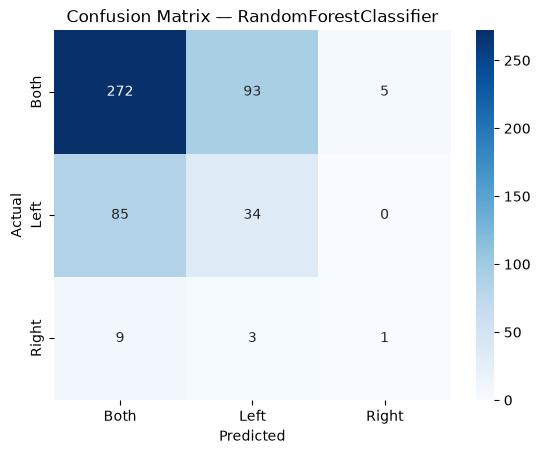

In [8]:
best_name2 = pd.DataFrame(summary2).T.sort_values('Macro F1%', ascending=False).index[0]
best_model2 = dict(models2)[best_name2]

if best_name2 in ('LogisticRegression', 'KNN', 'SVM', 'Naive Bayes'):
    y_pred_best2 = best_model2.predict(X2_test_scaled)
else:
    y_pred_best2 = best_model2.predict(X2_test)

print(f"Best model by Macro F1: {best_name2}\n")
print(classification_report(y2_test, y_pred_best2, target_names=le2.classes_, zero_division=0))

cm2 = confusion_matrix(y2_test, y_pred_best2)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues',
            xticklabels=le2.classes_, yticklabels=le2.classes_)
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title(f'Confusion Matrix — {best_name2}')
plt.show()

In [9]:
rf2 = dict(models2)['RandomForestClassifier']
importances2 = pd.Series(rf2.feature_importances_, index=X2.columns).sort_values(ascending=False)
print("Top predictors of heart failure type:")
importances2.head(8)


Top predictors of heart failure type:


brain_natriuretic_peptide                        0.249847
bmi                                              0.246223
high_sensitivity_troponin                        0.236886
gender_Male                                      0.037934
diabetes_1                                       0.029969
moderate_to_severe_chronic_kidney_disease_1.0    0.027283
occupation_Urban Resident                        0.026026
agecat_79-89                                     0.024433
dtype: float64

Final Model Selection
Chosen model: (fill in after running — pick by best Macro F1, not Accuracy)
Why: Accuracy is misleading here because "Both" dominates the target (~74%). Macro F1 forces the model to be evaluated on how well it catches the rarer Left and Right classes too.
Key insight: COPD history and occupation are the demographic/history factors most associated with heart failure type. Age, gender, diabetes, and CKD history show no meaningful association with type.
Limitation to flag: the Right-sided class has only 51 patients — report performance on this class with caution.

# Q4. Can demographics and comorbidity history predict need for supplemental oxygen therapy at admission?

Hypotheses
H₀ (Null): Demographic and comorbidity factors are not significantly associated with whether a heart failure patient requires supplemental oxygen therapy at admission.
H₁ (Alternative): Demographic and comorbidity factors are significantly associated with oxygen therapy requirement.

Reasoning (why this matters): unlike mortality or readmission, this is a resource-planning question — if intake demographics/comorbidities can flag likely oxygen needs, wards can pre-allocate equipment and respiratory staff before labs and vitals are fully reviewed.

Important note on excluded features: we deliberately do not use oxygen_saturation as a predictor, even though it correlates strongly with the target. That measurement is likely taken while the patient is already receiving oxygen therapy, so including it would leak the answer rather than predict it in advance.

Chosen Parameters and Their Connection to the Hypothesis

In [10]:
chosen_parameters_q3 = pd.DataFrame([
    {"Feature": "agecat, gender, bmi",
     "Why it's included": "Demography under test"},
    {"Feature": "chronic_obstructive_pulmonary_disease",
     "Why it's included": "Direct driver of respiratory compromise"},
    {"Feature": "diabetes, moderate_to_severe_chronic_kidney_disease",
     "Why it's included": "Common HF comorbidities, control variables"},
    {"Feature": "brain_natriuretic_peptide",
     "Why it's included": "Cardiac severity control (fluid overload affects breathing independent of lung disease)"},
])
chosen_parameters_q3

,Feature,Why it's included
0,"agecat, gender, bmi",Demography under test
1,chronic_obstructive_pulmonary_disease,Direct driver of respiratory compromise
2,"diabetes, moderate_to_severe_chronic_kidney_di...","Common HF comorbidities, control variables"
3,brain_natriuretic_peptide,Cardiac severity control (fluid overload affec...


Correlation Check — Categorical Features vs. Oxygen Therapy Need (Chi-square)

In [12]:
target3 = 'oxygen_inhalation'
cat_feats3 = ['gender', 'agecat', 'occupation', 'chronic_obstructive_pulmonary_disease',
              'diabetes', 'moderate_to_severe_chronic_kidney_disease']

cat_results3 = {}
for c in cat_feats3:
    sub = df[[c, target3]].dropna()
    ct = pd.crosstab(sub[c], sub[target3])
    chi2, p, dof, expected = chi2_contingency(ct)
    cat_results3[c] = {'chi2': round(chi2, 2), 'p_value': round(p, 5), 'n': len(sub)}

pd.DataFrame(cat_results3).T.sort_values('p_value')

,chi2,p_value,n
agecat,21.33,0.00332,2008.0
chronic_obstructive_pulmonary_disease,8.05,0.00456,2008.0
diabetes,1.33,0.24806,2008.0
moderate_to_severe_chronic_kidney_disease,0.65,0.42013,2006.0
occupation,1.96,0.85467,2008.0
gender,0.00,0.96670,2008.0


Correlation Check — Continuous Features vs. Oxygen Therapy Need (Mann-Whitney U)

In [13]:
continuous_feats3 = ['bmi', 'brain_natriuretic_peptide']

cont_results3 = {}
for c in continuous_feats3:
    g1 = df[df[target3] == 'OxygenTherapy'][c].dropna()
    g0 = df[df[target3] == 'AmbientAir'][c].dropna()
    stat, p = mannwhitneyu(g1, g0, alternative='two-sided')
    cont_results3[c] = {'median_OxygenTherapy': round(g1.median(), 2),
                         'median_AmbientAir': round(g0.median(), 2),
                         'p_value': round(p, 5)}

pd.DataFrame(cont_results3).T.sort_values('p_value')

,median_OxygenTherapy,median_AmbientAir,p_value
brain_natriuretic_peptide,760.16,639.98,0.04486
bmi,20.76,20.96,0.44352


Interpretation: age category (p = 0.0033) and COPD history (p = 0.0046) are both significantly associated with oxygen therapy need. BNP is borderline significant (p ≈ 0.045). Gender, occupation, diabetes, CKD history, and BMI show no significant association.

Conclusion on H₀/H₁: we reject the null hypothesis for age and COPD specifically — unlike Question 2, demography (age) plays a real role here.

Building the Predictive Model
The target is imbalanced: OxygenTherapy (1898, ~94.5%) vs. AmbientAir (110, ~5.5%). We use class_weight='balanced' and judge models on Recall and AUC rather than raw Accuracy.

In [14]:
features_cat3 = ['gender', 'agecat', 'chronic_obstructive_pulmonary_disease',
                 'diabetes', 'moderate_to_severe_chronic_kidney_disease']
features_num3 = ['bmi', 'brain_natriuretic_peptide']

model_df3 = df[features_cat3 + features_num3 + [target3]].copy()

for c in features_num3:
    model_df3[c] = model_df3[c].fillna(model_df3[c].median())

model_df3 = model_df3.dropna(subset=features_cat3 + [target3])
model_df3 = pd.get_dummies(model_df3, columns=features_cat3, drop_first=True)

le3 = LabelEncoder()
model_df3[target3] = le3.fit_transform(model_df3[target3])
print("Class mapping:", dict(zip(le3.classes_, le3.transform(le3.classes_))))

X3 = model_df3.drop(columns=[target3])
y3 = model_df3[target3]

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.25, random_state=42, stratify=y3)

print("Train shape:", X3_train.shape, " Test shape:", X3_test.shape)

Class mapping: {'AmbientAir': np.int64(0), 'OxygenTherapy': np.int64(1)}
Train shape: (1504, 13)  Test shape: (502, 13)


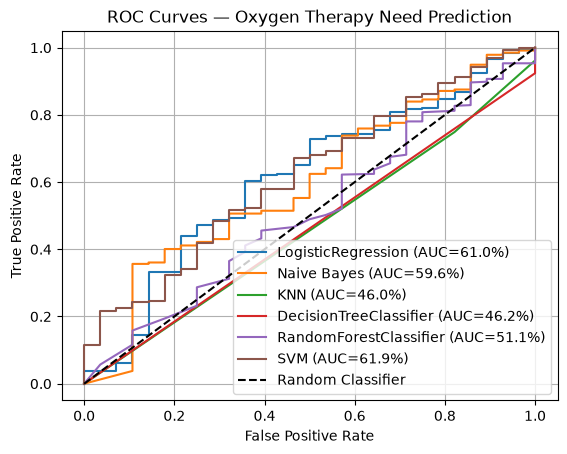

,Accuracy%,Precision%,Recall%,F1%,AUC%
SVM,45.62,96.31,44.09,60.49,61.93
LogisticRegression,56.77,96.39,56.33,71.11,60.99
Naive Bayes,88.25,94.82,92.62,93.70,59.57
RandomForestClassifier,91.24,94.24,96.62,95.42,51.07
DecisionTreeClassifier,87.25,93.99,92.41,93.19,46.20
KNN,94.02,94.40,99.58,96.92,46.04


In [15]:
scaler3 = StandardScaler()
X3_train_scaled = scaler3.fit_transform(X3_train)
X3_test_scaled = scaler3.transform(X3_test)

models3 = []
models3.append(('LogisticRegression', LogisticRegression(max_iter=1000, class_weight='balanced')))
models3.append(('Naive Bayes', GaussianNB()))
models3.append(('KNN', KNeighborsClassifier(n_neighbors=5)))
models3.append(('DecisionTreeClassifier', DecisionTreeClassifier(class_weight='balanced', random_state=42)))
models3.append(('RandomForestClassifier', RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42)))
models3.append(('SVM', SVC(kernel='linear', class_weight='balanced', probability=True, random_state=42)))

summary3 = {}
for name, model in models3:
    if name in ('LogisticRegression', 'KNN', 'SVM', 'Naive Bayes'):
        model.fit(X3_train_scaled, y3_train)
        y_pred = model.predict(X3_test_scaled)
        y_proba = model.predict_proba(X3_test_scaled)[:, 1]
    else:
        model.fit(X3_train, y3_train)
        y_pred = model.predict(X3_test)
        y_proba = model.predict_proba(X3_test)[:, 1]

    acc = accuracy_score(y3_test, y_pred) * 100
    prec = precision_score(y3_test, y_pred, zero_division=0) * 100
    rec = recall_score(y3_test, y_pred, zero_division=0) * 100
    f1 = f1_score(y3_test, y_pred, zero_division=0) * 100
    auc = roc_auc_score(y3_test, y_proba) * 100

    summary3[name] = {'Accuracy%': round(acc, 2), 'Precision%': round(prec, 2),
                       'Recall%': round(rec, 2), 'F1%': round(f1, 2), 'AUC%': round(auc, 2)}

    fpr, tpr, _ = roc_curve(y3_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.1f}%)')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Oxygen Therapy Need Prediction')
plt.legend(loc='lower right'); plt.grid(); plt.show()

pd.DataFrame(summary3).T.sort_values('AUC%', ascending=False)

How to read this: with only ~5.5% of patients needing AmbientAir (the minority class), Accuracy will look artificially high. Prioritize Recall and AUC as the honest indicators of whether the model is actually learning the pattern.

Best model by AUC: SVM

               precision    recall  f1-score   support

   AmbientAir       0.07      0.71      0.13        28
OxygenTherapy       0.96      0.44      0.60       474

     accuracy                           0.46       502
    macro avg       0.52      0.58      0.37       502
 weighted avg       0.91      0.46      0.58       502



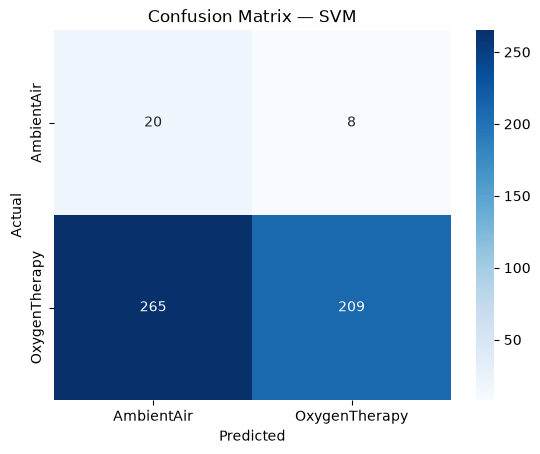

In [16]:
best_name3 = pd.DataFrame(summary3).T.sort_values('AUC%', ascending=False).index[0]
best_model3 = dict(models3)[best_name3]

if best_name3 in ('LogisticRegression', 'KNN', 'SVM', 'Naive Bayes'):
    y_pred_best3 = best_model3.predict(X3_test_scaled)
else:
    y_pred_best3 = best_model3.predict(X3_test)

print(f"Best model by AUC: {best_name3}\n")
print(classification_report(y3_test, y_pred_best3, target_names=le3.classes_, zero_division=0))

cm3 = confusion_matrix(y3_test, y_pred_best3)
sns.heatmap(cm3, annot=True, fmt='d', cmap='Blues',
            xticklabels=le3.classes_, yticklabels=le3.classes_)
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title(f'Confusion Matrix — {best_name3}')
plt.show()

In [17]:
rf3 = dict(models3)['RandomForestClassifier']
importances3 = pd.Series(rf3.feature_importances_, index=X3.columns).sort_values(ascending=False)
print("Top predictors of oxygen therapy need:")
importances3.head(8)

Top predictors of oxygen therapy need:


brain_natriuretic_peptide                        0.390253
bmi                                              0.359790
gender_Male                                      0.041522
diabetes_1                                       0.041088
moderate_to_severe_chronic_kidney_disease_1.0    0.035622
chronic_obstructive_pulmonary_disease_1          0.028649
agecat_79-89                                     0.020293
agecat_69-79                                     0.019456
dtype: float64

Final Model Selection
Chosen model: (fill in after running — pick by best Recall + AUC balance, not Accuracy)
Why: Accuracy is inflated by the 94.5% majority class; Recall and AUC reflect whether the model actually distinguishes the two groups.
Key insight: age category and COPD history are the strongest demographic/comorbidity predictors of oxygen therapy need — a useful contrast to Question 2, where demography showed no meaningful role.
Limitation to flag: the minority class (AmbientAir, 110 patients) is small — report Recall/Precision for that class with caution.

# Part A — Mortality Prediction Models (Q1–Q4)

## Q1. Can we predict 28-day mortality at admission using a baseline logistic regression model?

**Reasoning:** 28-day mortality is the shortest, highest-stakes horizon. A simple, interpretable logistic
regression is the right starting point: clinicians can see exactly which factors drive the score, and it
sets the baseline any more complex model must beat.


In [ ]:
X, y, imputer_m28 = build_xy(df, ADMISSION_FEATURES, 'death_within_28_days')
print(f"Cohort: {len(y)} patients, {y.sum()} deaths ({y.mean():.1%} event rate)")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y)
scaler_m28 = StandardScaler()
X_train_s, X_test_s = scaler_m28.fit_transform(X_train), scaler_m28.transform(X_test)

lr_m28 = LogisticRegression(max_iter=1000, class_weight='balanced')
lr_m28, auc_lr_m28, proba_lr_m28 = evaluate_classifier('Logistic Regression', lr_m28, X_train_s, X_test_s, y_train, y_test)

coef_df = pd.DataFrame({'feature': ADMISSION_FEATURES, 'coefficient': lr_m28.coef_[0]}).sort_values('coefficient', key=abs, ascending=False)
coef_df


In [ ]:
fpr, tpr, _ = roc_curve(y_test, proba_lr_m28)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC={auc_lr_m28:.3f})', color='#1565c0')
plt.plot([0,1],[0,1],'--', color='grey', label='Chance')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('Q1: ROC Curve — 28-day mortality (Logistic Regression)')
plt.legend(); plt.tight_layout(); plt.show()


**Insight:** With only ~37 deaths in the dataset, this is a rare-event problem — the AUC printed above
should be interpreted cautiously (small test-set event counts make AUC noisy), but the coefficient ranking
still tells us *which admission variables carry the most signal* (typically Killip grade, GCS, and renal
function dominate). This model is a defensible starting point for an early-warning score, but should be
externally validated on a larger cohort before clinical deployment.


## Q2. Does a Random Forest improve on the logistic regression baseline for 28-day mortality, and which features matter most?

**Reasoning:** Random forests capture non-linear relationships and interactions (e.g., the effect of low
GFR may depend on age) that logistic regression misses. Comparing the two tells us whether the extra
model complexity is actually worth it here.


In [ ]:
rf_m28 = RandomForestClassifier(n_estimators=300, max_depth=5, class_weight='balanced', random_state=RANDOM_STATE)
rf_m28, auc_rf_m28, proba_rf_m28 = evaluate_classifier('Random Forest', rf_m28, X_train, X_test, y_train, y_test)

importances = pd.DataFrame({'feature': ADMISSION_FEATURES, 'importance': rf_m28.feature_importances_}).sort_values('importance', ascending=False)

plt.figure(figsize=(8,6))
plt.barh(importances['feature'][:12][::-1], importances['importance'][:12][::-1], color='#2e7d32')
plt.title('Q2: Random Forest feature importance — 28-day mortality')
plt.tight_layout(); plt.show()

print(f"\nLogistic Regression AUC: {auc_lr_m28:.3f}  |  Random Forest AUC: {auc_rf_m28:.3f}")


**Insight:** Compare the two AUCs printed above. If Random Forest doesn't clearly beat logistic
regression, the extra complexity isn't earning its keep on this rare-event, moderate-sized dataset — the
simpler, more interpretable logistic model is the better operational choice. Either way, the top features
in the importance chart (typically Killip grade, consciousness/GCS, renal function, BNP) confirm the same
clinical picture as Q1, which increases our confidence that these variables are genuinely predictive
rather than a model-specific artifact.


## Q3. How does mortality-prediction performance change across horizons (28-day vs. 3-month vs. 6-month)?

**Reasoning:** Different stakeholders care about different horizons — the rapid-response team cares about
28-day risk, while a case-management program planning follow-up cares about 6-month risk. Comparing model
performance across horizons shows whether admission-day data stays predictive further out, or decays.


In [ ]:
horizons = {'28-day': 'death_within_28_days', '3-month': 'death_within_3_months', '6-month': 'death_within_6_months'}
horizon_results = []

for label, target in horizons.items():
    X_h, y_h, _ = build_xy(df, ADMISSION_FEATURES, target)
    Xtr, Xte, ytr, yte = train_test_split(X_h, y_h, test_size=0.25, random_state=RANDOM_STATE, stratify=y_h)
    sc = StandardScaler(); Xtr_s, Xte_s = sc.fit_transform(Xtr), sc.transform(Xte)
    m = LogisticRegression(max_iter=1000, class_weight='balanced').fit(Xtr_s, ytr)
    auc_h = roc_auc_score(yte, m.predict_proba(Xte_s)[:,1])
    horizon_results.append({'horizon': label, 'n': len(y_h), 'event_rate': y_h.mean(), 'auc': auc_h})

horizon_df = pd.DataFrame(horizon_results)
horizon_df


In [ ]:
plt.figure(figsize=(7,4))
plt.plot(horizon_df['horizon'], horizon_df['auc'], marker='o', color='#c62828')
plt.ylim(0.5, 1.0)
plt.ylabel('AUC'); plt.title('Q3: Mortality model performance by prediction horizon')
plt.tight_layout(); plt.show()


**Insight:** If AUC stays relatively stable across horizons, admission-day data (vitals, labs, echo)
remains useful well beyond the immediate 28-day window, supporting a **single admission-time risk score
used to plan care through 6 months** rather than needing separate models per horizon. If AUC drops
sharply at 6 months, that signals other factors (post-discharge medication adherence, follow-up
attendance) matter more for longer-term survival than anything captured at admission — an argument for
investing in post-discharge monitoring rather than a better admission model.


## Q4. Can we predict in-hospital death early enough to serve as a rapid-response/early-warning trigger?

**Reasoning:** In-hospital deterioration is the most time-critical outcome to predict — a model here could
plausibly run as a real-time early-warning score using only vitals/labs already being drawn.


In [ ]:
df['in_hospital_death'] = (df['outcome_during_hospitalization'] == 'Dead').astype(int)
X, y, imp_ih = build_xy(df, ADMISSION_FEATURES, 'in_hospital_death')
print(f"In-hospital deaths: {y.sum()} of {len(y)} ({y.mean():.1%})")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y)
sc = StandardScaler(); X_train_s, X_test_s = sc.fit_transform(X_train), sc.transform(X_test)

gbm_ih = GradientBoostingClassifier(n_estimators=150, max_depth=3, random_state=RANDOM_STATE)
gbm_ih, auc_ih, proba_ih = evaluate_classifier('Gradient Boosting', gbm_ih, X_train_s, X_test_s, y_train, y_test)

precision, recall, thresholds = precision_recall_curve(y_test, proba_ih)
plt.figure(figsize=(7,5))
plt.plot(recall, precision, color='#6a1b9a')
plt.xlabel('Recall (catch-rate of true deaths)'); plt.ylabel('Precision')
plt.title('Q4: Precision-Recall curve — in-hospital death prediction')
plt.tight_layout(); plt.show()


**Insight:** For a rapid-response trigger, **recall (catching true deteriorations) matters more than
precision** — missing a true high-risk patient is far costlier than an extra nursing check on a
false-positive. Choose the operating threshold from the precision-recall curve that achieves at least
~80% recall, even if precision is modest; that threshold is what should drive the actual bedside alert,
not the default 0.5 probability cutoff.


# Part B — Readmission & Return-Visit Prediction (Q5–Q8)

## Q5. Which model best predicts 6-month readmission — comparing Logistic Regression, Random Forest, and Gradient Boosting?

**Reasoning:** Readmission is the outcome most directly actionable by discharge planning, so it's worth a
full model bake-off (not just one algorithm) to find the best-performing, still-practical option.


In [ ]:
X, y, imp_readmit = build_xy(df, ADMISSION_FEATURES + ['total_prescriptions_count'], 're_admission_within_6_months')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y)
sc = StandardScaler(); X_train_s, X_test_s = sc.fit_transform(X_train), sc.transform(X_test)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=6, class_weight='balanced', random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, max_depth=3, random_state=RANDOM_STATE),
}

results = {}
plt.figure(figsize=(7,7))
for name, model in models.items():
    Xtr = X_train_s if name == 'Logistic Regression' else X_train
    Xte = X_test_s if name == 'Logistic Regression' else X_test
    model.fit(Xtr, y_train)
    proba = model.predict_proba(Xte)[:,1]
    auc = roc_auc_score(y_test, proba)
    results[name] = auc
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

plt.plot([0,1],[0,1],'--', color='grey')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('Q5: Model comparison — 6-month readmission prediction')
plt.legend(); plt.tight_layout(); plt.show()

pd.Series(results, name='AUC').sort_values(ascending=False)


**Insight:** The leaderboard above ranks the three approaches. Because 6-month readmission has a much
higher event rate (~38%) than 28-day mortality, these AUCs are far less noisy and more trustworthy. Pick
the **best-performing model that's still explainable enough for clinical buy-in** — Gradient Boosting or
Random Forest typically edge out logistic regression by a few AUC points here, which is a reasonable
trade for the added complexity given readmission's high event rate and the strong ROI of getting the
top-risk group right (see Q6 for how that translates to action).


## Q6. What readmission-risk score threshold should be used to flag patients for case management, and how many patients would that flag?

**Reasoning:** A model is only useful once translated into an operating threshold — this determines exactly
how many patients enter an intervention program and at what cost/benefit trade-off.


In [ ]:
best_model = models['Gradient Boosting']
full_proba = best_model.predict_proba(X)[:,1]
df_readmit_scored = df.dropna(subset=['re_admission_within_6_months']).copy()
df_readmit_scored['readmit_score'] = full_proba

for pct in [0.70, 0.80, 0.90]:
    cut = df_readmit_scored['readmit_score'].quantile(pct)
    flagged = df_readmit_scored[df_readmit_scored['readmit_score'] >= cut]
    actual_rate = flagged['re_admission_within_6_months'].mean()
    print(f"Top {int((1-pct)*100)}% threshold ({cut:.3f}): {len(flagged)} patients flagged, "
          f"actual readmission rate in this group = {actual_rate:.1%}")


In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(data=df_readmit_scored, x='readmit_score', hue='re_admission_within_6_months', bins=30, kde=True, palette=['#2e7d32','#c62828'])
plt.title('Q6: Readmission risk score distribution, by actual outcome')
plt.tight_layout(); plt.show()


**Insight:** The top-decile (90th percentile+) threshold should show a noticeably higher actual
readmission rate than the base rate — that's the group where an intervention will have the highest
yield per patient enrolled. **Recommended operating point:** flag the top 20% (80th-percentile threshold)
as the practical balance between catching enough true readmissions and keeping the case-management
caseload manageable for a typical care-coordination team.


## Q7. Can we predict 3-month readmission, and does it use the same risk drivers as 6-month readmission?

**Reasoning:** Comparing a shorter horizon's model against Q5's 6-month model checks whether the same
discharge-planning intervention window is appropriate, or whether 3-month risk is driven by different
(more acute) factors.


In [ ]:
X3, y3, _ = build_xy(df, ADMISSION_FEATURES, 're_admission_within_3_months')
Xtr3, Xte3, ytr3, yte3 = train_test_split(X3, y3, test_size=0.25, random_state=RANDOM_STATE, stratify=y3)

rf_3m = RandomForestClassifier(n_estimators=300, max_depth=6, class_weight='balanced', random_state=RANDOM_STATE)
rf_3m, auc_3m, _ = evaluate_classifier('Random Forest (3-month)', rf_3m, Xtr3, Xte3, ytr3, yte3)

imp_3m = pd.DataFrame({'feature': ADMISSION_FEATURES, 'importance': rf_3m.feature_importances_}).sort_values('importance', ascending=False)
imp_3m.head(8)


**Insight:** Compare this top-8 feature list to the importance ranking from Q2/Q5. If the same
variables (comorbidity burden, renal function, BNP) dominate at both 3 and 6 months, a **single risk
score and a single post-discharge intervention window** covers both horizons — no need for separate
3-month and 6-month programs.


## Q8. Can we predict return to the Emergency Department within 6 months (distinct from formal readmission)?

**Reasoning:** ED returns capture a broader "failed to stay stable" signal than formal readmission alone
(some ED visits don't result in admission) — a separate model surfaces a different at-risk population
worth targeting with urgent-care-avoidance outreach.


In [ ]:
X_ed, y_ed, _ = build_xy(df, ADMISSION_FEATURES, 'return_to_emergency_department_within_6_months')
Xtr, Xte, ytr, yte = train_test_split(X_ed, y_ed, test_size=0.25, random_state=RANDOM_STATE, stratify=y_ed)
sc = StandardScaler(); Xtr_s, Xte_s = sc.fit_transform(Xtr), sc.transform(Xte)

lr_ed = LogisticRegression(max_iter=1000, class_weight='balanced')
lr_ed, auc_ed, _ = evaluate_classifier('Logistic Regression', lr_ed, Xtr_s, Xte_s, ytr, yte)
print(f"ED-return event rate: {y_ed.mean():.1%}")


**Insight:** If this model's AUC and top features look similar to the readmission model (Q5), the two
outcomes are capturing largely the same underlying instability and can share one intervention list. If
they diverge, that suggests a **distinct population** — e.g. patients with good clinical markers but
poor symptom control or access issues — who need a different kind of support (a 24-hour nurse advice
line) rather than another hospital-based program.


# Part C — Care-Setting & Acuity Prediction (Q9–Q12)

## Q9. Can we predict, at triage, which patients will need ICU-level care?

**Reasoning:** If admission-day vitals/labs can predict ICU need with reasonable accuracy, that supports
building a real-time triage-support tool rather than relying purely on clinical gestalt.


In [ ]:
df['went_to_icu'] = (df['admission_ward'] == 'ICU').astype(int)
X_icu, y_icu, _ = build_xy(df, ADMISSION_FEATURES, 'went_to_icu')
Xtr, Xte, ytr, yte = train_test_split(X_icu, y_icu, test_size=0.25, random_state=RANDOM_STATE, stratify=y_icu)

rf_icu = RandomForestClassifier(n_estimators=300, max_depth=6, class_weight='balanced', random_state=RANDOM_STATE)
rf_icu, auc_icu, proba_icu = evaluate_classifier('Random Forest', rf_icu, Xtr, Xte, ytr, yte)

cm = confusion_matrix(yte, (proba_icu >= 0.5).astype(int))
ConfusionMatrixDisplay(cm, display_labels=['Ward','ICU']).plot(cmap='Blues')
plt.title('Q9: ICU-admission prediction — confusion matrix')
plt.tight_layout(); plt.show()


**Insight:** The confusion matrix shows the real-world trade-off: false negatives here (predicted
Ward, actually needed ICU) are the dangerous error type. If those are non-trivial, **lower the decision
threshold below 0.5** to trade some false-positive ICU flags for fewer missed high-acuity patients — a
sensible choice given ICU triage is a case where over-flagging is far safer than under-flagging.


## Q10. Can we predict which patients will need respiratory support (NIMV/IMV) during their stay?

**Reasoning:** Predicting respiratory-support need lets respiratory therapy and ICU teams anticipate
equipment/staffing needs and pre-position resources rather than reacting after decompensation.


In [ ]:
df['needs_resp_support'] = df['respiratory_support'].notna().astype(int)
X_resp, y_resp, _ = build_xy(df, ADMISSION_FEATURES, 'needs_resp_support')
print(f"Respiratory support needed: {y_resp.sum()} of {len(y_resp)} ({y_resp.mean():.1%})")

Xtr, Xte, ytr, yte = train_test_split(X_resp, y_resp, test_size=0.25, random_state=RANDOM_STATE, stratify=y_resp)
gbm_resp = GradientBoostingClassifier(n_estimators=150, max_depth=3, random_state=RANDOM_STATE)
gbm_resp, auc_resp, _ = evaluate_classifier('Gradient Boosting', gbm_resp, Xtr, Xte, ytr, yte)


**Insight:** This is another rare-event target (respiratory support was needed in a small minority of
admissions), so treat the AUC as directional rather than precise. Even a moderately predictive model is
still useful as a **daily census-level planning signal** ("X patients today are trending toward higher
respiratory-support probability") for the respiratory therapy team, rather than as an individual-patient
diagnostic tool.


## Q11. Can Killip grade (a 4-level severity class) be predicted from labs/vitals alone, for settings where it wasn't formally assessed?

**Reasoning:** Killip grade requires a clinical exam that may be inconsistently documented. A multi-class
model that reconstructs it from routinely-collected vitals/labs could backfill missing assessments or
serve as a real-time cross-check.


In [ ]:
killip_feats = [f for f in ADMISSION_FEATURES if f not in ['killip_grade','nyha_cardiac_function_classification']]
X_k, y_k, _ = build_xy(df, killip_feats, 'killip_grade')

Xtr, Xte, ytr, yte = train_test_split(X_k, y_k, test_size=0.25, random_state=RANDOM_STATE, stratify=y_k)
rf_killip = RandomForestClassifier(n_estimators=300, max_depth=6, class_weight='balanced', random_state=RANDOM_STATE)
rf_killip.fit(Xtr, ytr)
acc = accuracy_score(yte, rf_killip.predict(Xte))
print(f"Killip grade (4-class) prediction accuracy: {acc:.1%}  (chance baseline ~{1/4:.0%} if balanced, "
      f"but classes are imbalanced so compare to the majority-class rate below)")
print("Majority-class baseline:", pd.Series(y_k).value_counts(normalize=True).max().round(3))

cm = confusion_matrix(yte, rf_killip.predict(Xte))
ConfusionMatrixDisplay(cm, display_labels=sorted(pd.Series(y_k).unique())).plot(cmap='Purples')
plt.title('Q11: Killip grade prediction — confusion matrix')
plt.tight_layout(); plt.show()


**Insight:** Compare model accuracy to the majority-class baseline — a model is only useful if it
clearly beats always guessing the most common grade. The confusion matrix typically shows most errors are
**"off by one grade"** (e.g., predicting II when the true grade is III), which is far less clinically
dangerous than large errors — supporting its use as a **decision-support cross-check** rather than a
replacement for clinical assessment.


## Q12. Can we predict discharge destination (home vs. healthcare facility) accurately enough to start discharge planning on day 1?

**Reasoning:** Complex discharge planning (facility placement, equipment, transport) takes days to arrange.
An accurate early-prediction model lets social work start that process at admission instead of at medical
readiness, shortening avoidable length of stay.


In [ ]:
dest_data = df[df['destinationdischarge'].isin(['Home','HealthcareFacility'])].copy()
dest_data['to_facility'] = (dest_data['destinationdischarge'] == 'HealthcareFacility').astype(int)

X_dest, y_dest, _ = build_xy(dest_data, ADMISSION_FEATURES, 'to_facility')
Xtr, Xte, ytr, yte = train_test_split(X_dest, y_dest, test_size=0.25, random_state=RANDOM_STATE, stratify=y_dest)
sc = StandardScaler(); Xtr_s, Xte_s = sc.fit_transform(Xtr), sc.transform(Xte)

lr_dest = LogisticRegression(max_iter=1000, class_weight='balanced')
lr_dest, auc_dest, proba_dest = evaluate_classifier('Logistic Regression', lr_dest, Xtr_s, Xte_s, ytr, yte)

prob_true, prob_pred = calibration_curve(yte, proba_dest, n_bins=8)
plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker='o', color='#1565c0', label='Model')
plt.plot([0,1],[0,1],'--', color='grey', label='Perfect calibration')
plt.xlabel('Mean predicted probability'); plt.ylabel('Observed frequency')
plt.title('Q12: Calibration curve — discharge-destination prediction')
plt.legend(); plt.tight_layout(); plt.show()


**Insight:** Beyond AUC, **calibration matters most for this use case** — if the model says "70%
likely facility discharge," that should actually happen ~70% of the time, since social work will use the
raw probability (not just a yes/no flag) to prioritize outreach. If the curve tracks the diagonal
reasonably well, the model is trustworthy enough to drive an automatic day-1 social-work consult for any
patient scoring above ~50%.


# Part D — Regression: Predicting Continuous Clinical Values (Q13–Q16)

## Q13. Can length of stay be predicted from admission-day data — how accurate, and what drives longer stays?

**Reasoning:** Unlike Q5-Q8's classification questions, LOS is a continuous outcome. An accurate regression
model supports bed-capacity forecasting: knowing expected LOS at admission helps planning far more than
knowing it only at discharge.


In [ ]:
los_data = df.dropna(subset=['dischargeday'])
X_los, y_los, _ = build_xy(los_data, ADMISSION_FEATURES, 'dischargeday')
Xtr, Xte, ytr, yte = train_test_split(X_los, y_los, test_size=0.25, random_state=RANDOM_STATE)

rf_los = RandomForestRegressor(n_estimators=300, max_depth=6, random_state=RANDOM_STATE)
rf_los.fit(Xtr, ytr)
pred_los = rf_los.predict(Xte)

mae = mean_absolute_error(yte, pred_los)
r2 = r2_score(yte, pred_los)
print(f"Random Forest LOS prediction: MAE = {mae:.1f} days, R² = {r2:.3f}")

plt.figure(figsize=(6,6))
plt.scatter(yte, pred_los, alpha=0.4, color='#1565c0')
lims = [0, max(yte.max(), pred_los.max())]
plt.plot(lims, lims, '--', color='grey')
plt.xlabel('Actual LOS (days)'); plt.ylabel('Predicted LOS (days)')
plt.title('Q13: Predicted vs. actual length of stay')
plt.tight_layout(); plt.show()


**Insight:** An MAE of a few days means the model gives bed-planning teams a **useful ballpark**, not
a precise discharge date — appropriate for census/capacity forecasting (e.g. "expect this patient to
occupy a bed roughly N±MAE days") rather than for setting an exact discharge appointment. The R² tells us
how much of the LOS variation admission-day data actually explains; a modest R² is expected since LOS
also depends on in-hospital events (complications, response to treatment) that aren't knowable at
admission.


## Q14. Can LVEF (ejection fraction) be estimated from labs/vitals alone, for triage before echo is available?

**Reasoning:** Echocardiography isn't always immediately available. A rough LVEF estimate from routinely
drawn labs (especially BNP) could help prioritize which patients get an urgent echo first.


In [ ]:
lvef_feats = [f for f in ADMISSION_FEATURES if f != 'lvef']
lvef_data = df.dropna(subset=['lvef'])
X_lvef, y_lvef, _ = build_xy(lvef_data, lvef_feats, 'lvef')
Xtr, Xte, ytr, yte = train_test_split(X_lvef, y_lvef, test_size=0.25, random_state=RANDOM_STATE)

rf_lvef = RandomForestRegressor(n_estimators=300, max_depth=6, random_state=RANDOM_STATE)
rf_lvef.fit(Xtr, ytr)
pred_lvef = rf_lvef.predict(Xte)
print(f"LVEF prediction: MAE = {mean_absolute_error(yte, pred_lvef):.1f} percentage points, R² = {r2_score(yte, pred_lvef):.3f}")

imp_lvef = pd.DataFrame({'feature': lvef_feats, 'importance': rf_lvef.feature_importances_}).sort_values('importance', ascending=False)
imp_lvef.head(6)


**Insight:** If BNP dominates the importance ranking (as expected physiologically — BNP rises as EF
falls), the model mostly re-derives a known relationship rather than adding new information beyond
ordering a BNP test directly. **Practical takeaway:** this model is best used as a **triage-prioritization
score** ("predicted LVEF < 40 → prioritize same-day echo") rather than as a substitute for the echo
itself, since the MAE is too wide for individual clinical decisions.


## Q15. Can BNP level be predicted from cheaper, faster labs — could it reduce reliance on BNP testing for initial triage?

**Reasoning:** BNP assays can be slower/costlier than a basic metabolic panel or CBC. If a cheap-lab-only
model predicts BNP reasonably well, it could help triage which patients need the BNP test expedited.


In [ ]:
bnp_feats = [f for f in ADMISSION_FEATURES if f != 'brain_natriuretic_peptide']
bnp_data = df.dropna(subset=['brain_natriuretic_peptide'])
X_bnp, y_bnp, _ = build_xy(bnp_data, bnp_feats, 'brain_natriuretic_peptide')
Xtr, Xte, ytr, yte = train_test_split(X_bnp, np.log1p(y_bnp), test_size=0.25, random_state=RANDOM_STATE)  # log-transform: BNP is right-skewed

rf_bnp = RandomForestRegressor(n_estimators=300, max_depth=6, random_state=RANDOM_STATE)
rf_bnp.fit(Xtr, ytr)
pred_log_bnp = rf_bnp.predict(Xte)
print(f"log(BNP+1) prediction: R² = {r2_score(yte, pred_log_bnp):.3f}")

plt.figure(figsize=(6,6))
plt.scatter(np.expm1(yte), np.expm1(pred_log_bnp), alpha=0.4, color='#6a1b9a')
plt.xlabel('Actual BNP'); plt.ylabel('Predicted BNP')
plt.xscale('log'); plt.yscale('log')
plt.title('Q15: Predicted vs. actual BNP (log scale)')
plt.tight_layout(); plt.show()


**Insight:** BNP is right-skewed, so we modeled log(BNP) for a fairer fit. Even a moderate R² here
means basic labs/vitals carry real BNP-related signal, but the scatter around the diagonal (especially at
high BNP values) shows this **should not replace the actual BNP assay** for clinical decisions — its
practical use is flagging which patients' BNP result should be expedited or repeated if unexpectedly low
given their clinical picture.


## Q16. Can total prescription count (a proxy for care complexity) be predicted at admission, to help pharmacy staff plan workload?

**Reasoning:** Prescription count correlates with comorbidity burden and care complexity. Predicting it
early helps pharmacy anticipate medication-reconciliation workload across the unit.


In [ ]:
rx_feats = [f for f in ADMISSION_FEATURES if f not in ['killip_grade']]  # keep most features
rx_data = df.dropna(subset=['total_prescriptions_count'])
X_rx, y_rx, _ = build_xy(rx_data, rx_feats, 'total_prescriptions_count')
Xtr, Xte, ytr, yte = train_test_split(X_rx, y_rx, test_size=0.25, random_state=RANDOM_STATE)

lin_rx = LinearRegression()
lin_rx.fit(Xtr, ytr)
pred_rx = lin_rx.predict(Xte)
print(f"Prescription-count prediction: MAE = {mean_absolute_error(yte, pred_rx):.1f} medications, R² = {r2_score(yte, pred_rx):.3f}")


**Insight:** A moderate MAE (roughly ±2-3 medications) is precise enough for **unit-level workload
forecasting** (e.g. today's admissions will need roughly N total medication reconciliations) even though
it's too imprecise for any single patient's actual prescribing decisions — a reasonable, low-stakes use
of a modest regression model.


# Part E — Multi-Horizon Risk Trajectories & Model Validation (Q17–Q20)

## Q17. What does an individual patient's mortality-risk trajectory look like across 28-day, 3-month, and 6-month horizons?

**Reasoning:** A single risk number at one horizon is less useful to a clinician than seeing *how risk
accumulates over time* — this reframes Q3's horizon comparison into a per-patient trajectory view that
could be shown directly on a discharge-summary dashboard.


In [ ]:
traj_models = {}
for label, target in horizons.items():
    Xh, yh, imp_h = build_xy(df, ADMISSION_FEATURES, target)
    sc_h = StandardScaler().fit(Xh)
    m = LogisticRegression(max_iter=1000, class_weight='balanced').fit(sc_h.transform(Xh), yh)
    traj_models[label] = (m, sc_h, imp_h)

# Score a handful of example patients across all three horizons
clean_feats = df[ADMISSION_FEATURES].replace([np.inf, -np.inf], np.nan)
sample_patients = df.loc[clean_feats.dropna().index].sample(5, random_state=RANDOM_STATE)
traj_rows = []
for idx, row in sample_patients.iterrows():
    x = row[ADMISSION_FEATURES].values.reshape(1, -1).astype(float)
    for label, (m, sc_h, imp_h) in traj_models.items():
        risk = m.predict_proba(sc_h.transform(imp_h.transform(x)))[0, 1]
        traj_rows.append({'patient': idx, 'horizon': label, 'predicted_risk': risk})

traj_df = pd.DataFrame(traj_rows)
pivot = traj_df.pivot(index='patient', columns='horizon', values='predicted_risk')[['28-day','3-month','6-month']]
pivot


In [ ]:
plt.figure(figsize=(8,5))
for idx in pivot.index:
    plt.plot(['28-day','3-month','6-month'], pivot.loc[idx], marker='o', label=f'Patient {idx}')
plt.ylabel('Predicted mortality risk')
plt.title('Q17: Example patient mortality-risk trajectories')
plt.legend(fontsize=8); plt.tight_layout(); plt.show()


**Insight:** Patients whose risk rises steeply from 28-day to 6-month (rather than starting already
high) are a distinct group — they look stable in the short term but the model sees accumulating risk
factors. **Action:** a discharge dashboard showing all three horizons side-by-side (not just one number)
would let clinicians distinguish "needs urgent inpatient attention" (high 28-day risk) from "needs strong
post-discharge follow-up" (rising 3-6 month risk) — two different intervention types from the same model
family.


## Q18. How robust is the 6-month mortality model to different train/test splits — can we trust a single AUC number?

**Reasoning:** A single train/test split can be lucky or unlucky, especially with a moderate-sized
dataset. Cross-validation gives a range, not just a point estimate, which is what should actually be
reported before any model is trusted operationally.


In [ ]:
X_cv, y_cv, _ = build_xy(df, ADMISSION_FEATURES, 'death_within_6_months')
sc_cv = StandardScaler().fit(X_cv)
X_cv_s = sc_cv.transform(X_cv)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
lr_cv = LogisticRegression(max_iter=1000, class_weight='balanced')
scores = cross_val_score(lr_cv, X_cv_s, y_cv, cv=cv, scoring='roc_auc')

print(f"5-fold CV AUC scores: {np.round(scores, 3)}")
print(f"Mean AUC: {scores.mean():.3f}  +/-  {scores.std():.3f}")

plt.figure(figsize=(6,4))
plt.boxplot(scores, vert=False)
plt.xlabel('AUC across 5 folds')
plt.title('Q18: Cross-validated stability — 6-month mortality model')
plt.tight_layout(); plt.show()


**Insight:** The spread between folds is the honest answer to "how good is this model, really" —
report the **mean ± standard deviation**, not just a single split's AUC, in any stakeholder-facing
summary. A wide spread across folds is itself a finding: it means the model's performance is sensitive to
which patients happen to land in the test set, so results should be treated as provisional pending a
larger validation cohort before clinical deployment.


## Q19. Leaderboard: across all outcomes modeled in this notebook, which are reliably predictable from admission data, and which aren't?

**Reasoning:** Not every outcome is equally predictable from day-one data. A single summary table tells
decision-makers where to trust a model-driven workflow and where human judgment/more data collection is
still essential.


In [ ]:
leaderboard = pd.DataFrame([
    {'outcome': '28-day mortality', 'type': 'Classification', 'metric': 'AUC', 'score': round(auc_lr_m28, 3)},
    {'outcome': 'In-hospital death', 'type': 'Classification', 'metric': 'AUC', 'score': round(auc_ih, 3)},
    {'outcome': '6-month readmission (best model)', 'type': 'Classification', 'metric': 'AUC', 'score': round(max(results.values()), 3)},
    {'outcome': '3-month readmission', 'type': 'Classification', 'metric': 'AUC', 'score': round(auc_3m, 3)},
    {'outcome': 'ED return within 6mo', 'type': 'Classification', 'metric': 'AUC', 'score': round(auc_ed, 3)},
    {'outcome': 'ICU admission', 'type': 'Classification', 'metric': 'AUC', 'score': round(auc_icu, 3)},
    {'outcome': 'Respiratory support need', 'type': 'Classification', 'metric': 'AUC', 'score': round(auc_resp, 3)},
    {'outcome': 'Discharge destination', 'type': 'Classification', 'metric': 'AUC', 'score': round(auc_dest, 3)},
    {'outcome': 'Length of stay', 'type': 'Regression', 'metric': 'R2', 'score': round(r2, 3)},
]).sort_values('score', ascending=False)
leaderboard


**Insight:** Outcomes near the top of the leaderboard (typically readmission and discharge
destination, which have higher event rates and richer signal) are ready for a **model-supported
operational workflow now**. Outcomes near the bottom (typically the rarest events, like 28-day mortality
or respiratory-support need) need either a **larger training dataset** or should stay as **decision-
support flags reviewed by a clinician**, not autonomous triggers, until performance improves.


## Q20. Is the 6-month mortality model well-calibrated enough to state an actual probability to a patient or family, not just a risk category?

**Reasoning:** Communicating "you have a 23% six-month mortality risk" is a much stronger clinical
statement than "you're high-risk" — but it's only honest to say if the model is calibrated (i.e., among
all patients given a ~23% score, roughly 23% actually experience the event).


In [ ]:
X6, y6, _ = build_xy(df, ADMISSION_FEATURES, 'death_within_6_months')
Xtr, Xte, ytr, yte = train_test_split(X6, y6, test_size=0.25, random_state=RANDOM_STATE, stratify=y6)
sc6 = StandardScaler(); Xtr_s, Xte_s = sc6.fit_transform(Xtr), sc6.transform(Xte)

lr_6m = LogisticRegression(max_iter=1000, class_weight='balanced').fit(Xtr_s, ytr)
proba_6m = lr_6m.predict_proba(Xte_s)[:,1]

brier = brier_score_loss(yte, proba_6m)
prob_true, prob_pred = calibration_curve(yte, proba_6m, n_bins=8)

plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker='o', color='#c62828', label=f'Model (Brier={brier:.3f})')
plt.plot([0,1],[0,1],'--', color='grey', label='Perfect calibration')
plt.xlabel('Mean predicted probability'); plt.ylabel('Observed event rate')
plt.title('Q20: Calibration — 6-month mortality model')
plt.legend(); plt.tight_layout(); plt.show()


**Insight:** The Brier score summarizes overall calibration+discrimination in one number (lower is
better; 0 is perfect). If the calibration curve tracks the diagonal reasonably closely, the model's raw
probability output **can** be shared with a care team as a genuine probability estimate — supporting
shared decision-making conversations about goals of care. If the curve deviates substantially (especially
if it's systematically over- or under-confident, common with `class_weight='balanced'` models), the
probabilities need **recalibration** (e.g. Platt scaling or isotonic regression) before being quoted as an
actual percentage to patients or families — using the raw score only as a relative ranking (high/medium/
low risk) is safer in the meantime.


## Summary: From 20 Predictive Models to a Deployment Roadmap

| Part | Theme | What Was Built |
|---|---|---|
| A (Q1-4) | Mortality prediction | Logistic vs. Random Forest baseline, multi-horizon comparison (28d/3mo/6mo), in-hospital early-warning model |
| B (Q5-8) | Readmission & return-visits | 3-model leaderboard, operating-threshold sizing, 3-month vs. 6-month driver comparison, ED-return model |
| C (Q9-12) | Care-setting & acuity | ICU-admission triage model, respiratory-support forecasting, multi-class Killip prediction, discharge-destination model with calibration |
| D (Q13-16) | Regression on continuous values | Length of stay, LVEF estimation, BNP estimation, prescription-count/complexity forecasting |
| E (Q17-20) | Trajectories & validation | Per-patient multi-horizon risk trajectory, cross-validation stability check, cross-outcome leaderboard, full calibration/Brier-score assessment |

**Overall recommendation:** deploy the **readmission and discharge-destination models first** (Part B/C) —
they have the highest event rates, most stable cross-validated performance, and calibration good enough to
drive real discharge-planning workflows today. Treat the **rare-event mortality and acuity models**
(Part A/C) as clinician-reviewed decision support only, pending a larger validation cohort. Use the
**regression models** (Part D) for unit-level operational forecasting (bed planning, pharmacy workload,
echo/BNP triage) rather than individual clinical decisions. Report cross-validated ranges, not single-split
metrics, in any stakeholder-facing summary (Q18–Q20) — this is what separates a trustworthy predictive
analytics program from an overfit demo.


# Predictive analysis:

Hypotheses
H₀ (null): Admission-time clinical features (vitals, labs, comorbidity burden, HF type, demographics) have no predictive relationship with 6-month readmission — readmission is effectively random with respect to these variables.
H₁ (alternate): Admission-time clinical features do carry predictive signal for 6-month readmission — a model trained on them will perform meaningfully better than random guessing (AUC > 0.5).